In [2]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.3 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 55.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 53.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 KB 31.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install scipy>=1.12.0 --upgrade -v

In [3]:
!pip install psutil

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install numpy==1.24.3

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 54.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


In [5]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 6.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


2025-08-05 22:01:37.959085: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754431297.981523    3772 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754431297.988866    3772 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754431298.005987    3772 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754431298.006124    3772 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754431298.006136    3772 computation_placer.cc:177] computation placer alr

ACTIVATION FUNCTIONS COMPARISON - SPIRAL DATASET

Experiment Configuration:
  Architecture: [16] hidden units
  Epochs: 40
  Batch size: 32

Generating spiral dataset...

Dataset info:
  Total samples: 2000
  Training samples: 1600
  Test samples: 400
  Noise level: 0.5


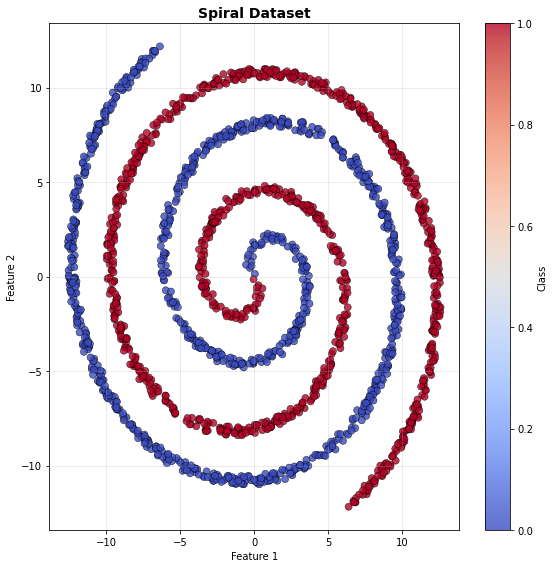


Training models with different activations...

Training with LASA activation...


I0000 00:00:1754431302.111311    3772 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1033 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6
I0000 00:00:1754431302.114471    3772 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46480 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:07:00.0, compute capability: 8.6


  Final Accuracy: 1.0000
  Final Loss: 0.0013

Training with RELU activation...
  Final Accuracy: 0.5950
  Final Loss: 0.5702

Training with LEAKY_RELU activation...
  Final Accuracy: 0.5475
  Final Loss: 0.5892

Training with ELU activation...
  Final Accuracy: 0.5500
  Final Loss: 0.6249

Training with SOFTPLUS activation...
  Final Accuracy: 0.5250
  Final Loss: 0.5966

Training with SWISH activation...
  Final Accuracy: 0.5775
  Final Loss: 0.5763

Training with MISH activation...
  Final Accuracy: 0.6175
  Final Loss: 0.5416

Training with GELU activation...
  Final Accuracy: 0.6600
  Final Loss: 0.5470

Training with SINE activation...
  Final Accuracy: 0.8925
  Final Loss: 0.2475

Training with SIGMOID activation...
  Final Accuracy: 0.5875
  Final Loss: 0.6315

Training with TANH activation...
  Final Accuracy: 0.6075
  Final Loss: 0.6310

FINAL RESULTS COMPARISON - SPIRAL DATASET
Rank   Activation      Accuracy     Final Loss  
-------------------------------------------------

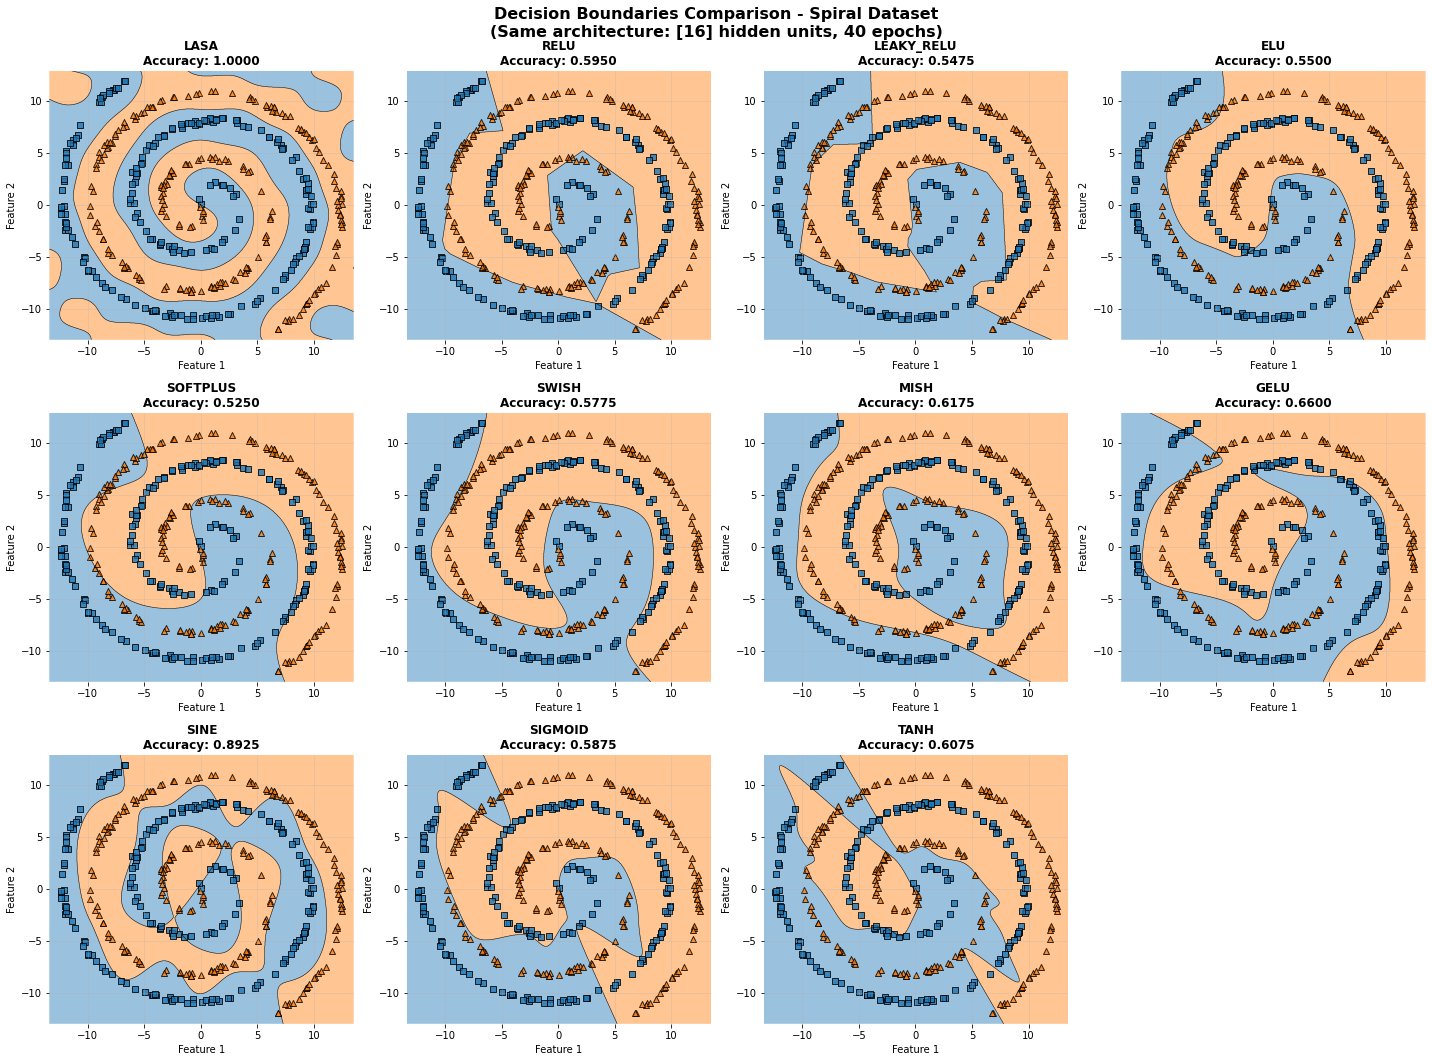

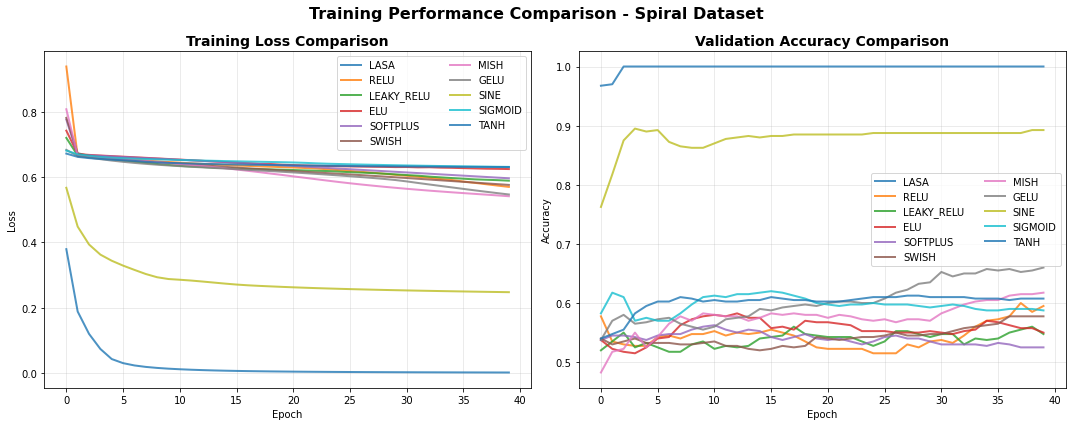

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Dataset Generation
# ============================================================================

def make_spiral(n_samples, noise=0.5):
    """Generate spiral dataset"""
    n = np.sqrt(np.random.rand(n_samples, 1)) * 780 * (2 * np.pi) / 360
    d1x = -np.cos(n) * n + np.random.rand(n_samples, 1) * noise
    d1y = np.sin(n) * n + np.random.rand(n_samples, 1) * noise
    X = np.vstack((np.hstack((d1x, d1y)), np.hstack((-d1x, -d1y))))
    y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
    return X, y.astype(np.int_)

# ============================================================================
# LASA Component
# ============================================================================

class LASAActivation(tf.keras.layers.Layer):
    """Layer-wise Adaptive Sine Activation (LASA) layer"""
    
    def __init__(self, initial_frequency=1.6, **kwargs):
        super().__init__(**kwargs)
        self.initial_frequency = initial_frequency
    
    def build(self, input_shape):
        self.tau = self.add_weight(
            shape=(), 
            initializer=tf.keras.initializers.Constant(self.initial_frequency),
            trainable=True, 
            name='tau'
        )
    
    def call(self, inputs):
        return tf.math.sin(self.tau * inputs)


# ============================================================================
# Custom Activation Layers
# ============================================================================

class MishActivation(tf.keras.layers.Layer):
    """Mish activation: x * tanh(softplus(x))"""
    def call(self, inputs):
        return inputs * tf.math.tanh(tf.math.softplus(inputs))


class SwishActivation(tf.keras.layers.Layer):
    """Swish activation: x * sigmoid(x)"""
    def call(self, inputs):
        return inputs * tf.nn.sigmoid(inputs)


# ============================================================================
# Universal Model Builder
# ============================================================================

def create_model(activation_type, hidden_units=[16], initial_frequency=1.6):
    """Create a model with specified activation function"""
    
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    
    for i, units in enumerate(hidden_units):
        # Add dense layer
        model.add(tf.keras.layers.Dense(units, name=f'dense_{i}'))
        
        # Add activation based on type
        if activation_type == 'lasa':
            model.add(LASAActivation(initial_frequency=initial_frequency, name=f'lasa_{i}'))
        elif activation_type == 'relu':
            model.add(tf.keras.layers.ReLU(name=f'relu_{i}'))
        elif activation_type == 'leaky_relu':
            model.add(tf.keras.layers.LeakyReLU(alpha=0.01, name=f'leaky_relu_{i}'))
        elif activation_type == 'elu':
            model.add(tf.keras.layers.ELU(alpha=1.0, name=f'elu_{i}'))
        elif activation_type == 'softplus':
            model.add(tf.keras.layers.Activation('softplus', name=f'softplus_{i}'))
        elif activation_type == 'swish':
            model.add(SwishActivation(name=f'swish_{i}'))
        elif activation_type == 'mish':
            model.add(MishActivation(name=f'mish_{i}'))
        elif activation_type == 'gelu':
            model.add(tf.keras.layers.Activation('gelu', name=f'gelu_{i}'))
        elif activation_type == 'sine':
            model.add(tf.keras.layers.Activation(tf.math.sin, name=f'sine_{i}'))
        elif activation_type == 'sigmoid':
            model.add(tf.keras.layers.Activation('sigmoid', name=f'sigmoid_{i}'))
        elif activation_type == 'tanh':
            model.add(tf.keras.layers.Activation('tanh', name=f'tanh_{i}'))
    
    # Output layer
    model.add(tf.keras.layers.Dense(1, activation='sigmoid', name='output'))
    
    return model


# ============================================================================
# Universal Trainer
# ============================================================================

class UniversalTrainer:
    """Trainer that works for all activation types"""
    
    def __init__(self, model, activation_type, lr_main=0.01, lr_tau=0.01):
        self.model = model
        self.activation_type = activation_type
        self.loss_fn = tf.keras.losses.BinaryCrossentropy()
        
        # For LASA, use separate optimizers
        if activation_type == 'lasa':
            self.optimizer_main = tf.keras.optimizers.Adam(learning_rate=lr_main)
            self.optimizer_tau = tf.keras.optimizers.Adam(learning_rate=lr_tau)
        else:
            self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_main)
    
    @tf.function
    def train_step_lasa(self, x_batch, y_batch):
        """Training step for LASA with separate tau optimization"""
        with tf.GradientTape() as tape:
            predictions = self.model(x_batch, training=True)
            y_batch = tf.reshape(y_batch, (-1, 1))
            loss = self.loss_fn(y_batch, predictions)
        
        grads = tape.gradient(loss, self.model.trainable_variables)
        
        tau_vars = [v for v in self.model.trainable_variables if 'tau' in v.name]
        other_vars = [v for v in self.model.trainable_variables if 'tau' not in v.name]
        
        tau_grads = [g for g, v in zip(grads, self.model.trainable_variables) if 'tau' in v.name]
        other_grads = [g for g, v in zip(grads, self.model.trainable_variables) if 'tau' not in v.name]
        
        self.optimizer_tau.apply_gradients(zip(tau_grads, tau_vars))
        self.optimizer_main.apply_gradients(zip(other_grads, other_vars))
        
        return loss
    
    @tf.function
    def train_step_regular(self, x_batch, y_batch):
        """Training step for regular activations"""
        with tf.GradientTape() as tape:
            predictions = self.model(x_batch, training=True)
            y_batch = tf.reshape(y_batch, (-1, 1))
            loss = self.loss_fn(y_batch, predictions)
        
        grads = tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
        
        return loss
    
    def train(self, X_train, y_train, X_test, y_test, epochs=40, batch_size=32, verbose=False):
        """Train the model"""
        history = {'loss': [], 'val_accuracy': []}
        
        for epoch in range(epochs):
            total_loss = 0.0
            num_batches = 0
            
            for i in range(0, len(X_train), batch_size):
                x_batch = X_train[i:i+batch_size]
                y_batch = y_train[i:i+batch_size]
                
                if self.activation_type == 'lasa':
                    batch_loss = self.train_step_lasa(x_batch, y_batch)
                else:
                    batch_loss = self.train_step_regular(x_batch, y_batch)
                
                total_loss += batch_loss.numpy()
                num_batches += 1
            
            avg_loss = total_loss / num_batches
            
            # Evaluation
            predictions = self.model(X_test)
            y_pred = (predictions > 0.5).numpy().astype(int).flatten()
            accuracy = np.mean(y_pred == y_test)
            
            history['loss'].append(avg_loss)
            history['val_accuracy'].append(accuracy)
            
            if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {accuracy:.4f}")
        
        return history


# ============================================================================
# Visualization Functions
# ============================================================================

def plot_dataset(X, y, title="Spiral Dataset"):
    """Plot the dataset"""
    plt.figure(figsize=(8, 8))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', 
                        edgecolors='black', linewidth=0.5, alpha=0.8, s=50)
    plt.colorbar(scatter, label='Class')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_all_decision_boundaries(models, results, X_test, y_test):
    """Plot decision boundaries for all activation functions"""
    
    # Create wrapper for mlxtend
    class ModelWrapper:
        def __init__(self, keras_model):
            self.model = keras_model
        
        def predict(self, X):
            return (self.model(X) > 0.5).numpy().astype(int).flatten()
    
    # Create subplots
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()
    
    activation_names = list(models.keys())
    
    for idx, activation in enumerate(activation_names):
        ax = axes[idx]
        model = models[activation]
        accuracy = results[activation]['accuracy']
        
        # Plot decision regions
        wrapper = ModelWrapper(model)
        plot_decision_regions(X=X_test, y=y_test, clf=wrapper, 
                            ax=ax, legend=0)
        
        # Set title with accuracy
        title = f"{activation.upper()}\nAccuracy: {accuracy:.4f}"
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Feature 1', fontsize=10)
        ax.set_ylabel('Feature 2', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    # Remove extra subplot if any
    if len(activation_names) < len(axes):
        for idx in range(len(activation_names), len(axes)):
            fig.delaxes(axes[idx])
    
    plt.suptitle('Decision Boundaries Comparison - Spiral Dataset\n(Same architecture: [16] hidden units, 40 epochs)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_training_curves_comparison(results):
    """Plot training curves for all activations"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    for activation, data in results.items():
        # Plot loss
        ax1.plot(data['history']['loss'], label=activation.upper(), linewidth=2, alpha=0.8)
        
        # Plot accuracy
        ax2.plot(data['history']['val_accuracy'], label=activation.upper(), linewidth=2, alpha=0.8)
    
    ax1.set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(loc='best', ncol=2)
    ax1.grid(True, alpha=0.3)
    
    ax2.set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend(loc='best', ncol=2)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Training Performance Comparison - Spiral Dataset', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


def print_comparison_table(results):
    """Print a formatted comparison table"""
    
    print("\n" + "="*60)
    print("FINAL RESULTS COMPARISON - SPIRAL DATASET")
    print("="*60)
    print(f"{'Rank':<6} {'Activation':<15} {'Accuracy':<12} {'Final Loss':<12}")
    print("-"*60)
    
    # Sort by accuracy
    sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
    
    for rank, (activation, data) in enumerate(sorted_results, 1):
        print(f"{rank:<6} {activation.upper():<15} {data['accuracy']:<12.4f} {data['final_loss']:<12.4f}")
    
    print("="*60)


# ============================================================================
# Comparison Experiment
# ============================================================================

def run_spiral_comparison(hidden_units=[16], initial_frequency=1.6,
                         n_samples=1000, noise=0.5, test_size=0.2,
                         epochs=40, batch_size=32, random_state=42):
    """Compare all activation functions on spiral dataset"""
    
    # Define all activation types to compare
    activation_types = [
        'lasa', 'relu', 'leaky_relu', 'elu', 'softplus', 
        'swish', 'mish', 'gelu', 'sine', 'sigmoid', 'tanh'
    ]
    
    # Generate dataset
    print("="*60)
    print("ACTIVATION FUNCTIONS COMPARISON - SPIRAL DATASET")
    print("="*60)
    print("\nExperiment Configuration:")
    print(f"  Architecture: {hidden_units} hidden units")
    print(f"  Epochs: {epochs}")
    print(f"  Batch size: {batch_size}")
    
    print("\nGenerating spiral dataset...")
    X, y = make_spiral(n_samples=n_samples, noise=noise)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    print(f"\nDataset info:")
    print(f"  Total samples: {n_samples * 2}")  # *2 because make_spiral generates 2n samples
    print(f"  Training samples: {len(X_train)}")
    print(f"  Test samples: {len(X_test)}")
    print(f"  Noise level: {noise}")
    
    # Plot the dataset
    plot_dataset(X, y)
    
    results = {}
    models = {}
    
    print("\nTraining models with different activations...")
    print("="*60)
    
    for activation in activation_types:
        print(f"\nTraining with {activation.upper()} activation...")
        
        # Create model
        model = create_model(activation, hidden_units, initial_frequency)
        
        # Train model
        trainer = UniversalTrainer(model, activation, lr_main=0.01, lr_tau=0.01)
        history = trainer.train(X_train, y_train, X_test, y_test, 
                              epochs=epochs, batch_size=batch_size, verbose=False)
        
        # Final evaluation
        predictions = model(X_test)
        y_pred = (predictions > 0.5).numpy().astype(int).flatten()
        final_accuracy = np.mean(y_pred == y_test)
        
        # Store results
        results[activation] = {
            'accuracy': final_accuracy,
            'history': history,
            'final_loss': history['loss'][-1]
        }
        models[activation] = model
        
        print(f"  Final Accuracy: {final_accuracy:.4f}")
        print(f"  Final Loss: {history['loss'][-1]:.4f}")
    
    return models, results, X, y, X_test, y_test


# ============================================================================
# Main Execution
# ============================================================================

if __name__ == "__main__":
    # Run the comparison experiment
    models, results, X, y, X_test, y_test = run_spiral_comparison(
        hidden_units=[16],
        initial_frequency=1.6,
        epochs=40,
        batch_size=32
    )
    
    # Print comparison table
    print_comparison_table(results)
    
    # Plot all decision boundaries
    plot_all_decision_boundaries(models, results, X_test, y_test)
    
    # Plot training curves
    plot_training_curves_comparison(results)